In [8]:
import sys
import os

cwd = os.getcwd()
print(cwd)
project_root = os.path.abspath(os.path.join(cwd, "../../.."))
sys.path.append(project_root)
sys.path.append(os.path.join(cwd, "XCP-explain"))

import cpmpy as cp
# reload cpmpy if changes made
import importlib
importlib.reload(cp)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import numpy as np
from visualize import *
from read_data import get_data
from factory import *
from cpmpy.tools.explain import marco
from cpmpy.tools.explain.utils import diversity_matrix
from cpmpy.tools.explain.diverse_enumeration import marco_select_top_k, marco_diverse, marco_until_diverse, ocus_enum
from cpmpy.tools.explain.visualize_diversity import visualize_heatmap

/Users/macbookpro/Desktop/cpmpy/cpmpy/tools/explain


# setup model

In [9]:

instance = os.path.join("XCP-explain","Benchmarks/CustomInstance.txt")
data = get_data(instance)
factory = NurseSchedulingFactory(data)
model, nurse_view = factory.get_decision_model()
cs = len(model.constraints)


## 1 MARCO

In [10]:
result = []
for i, (kind, subset) in enumerate(marco(model.constraints, solver="exact", map_solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    if i == 4:
        break

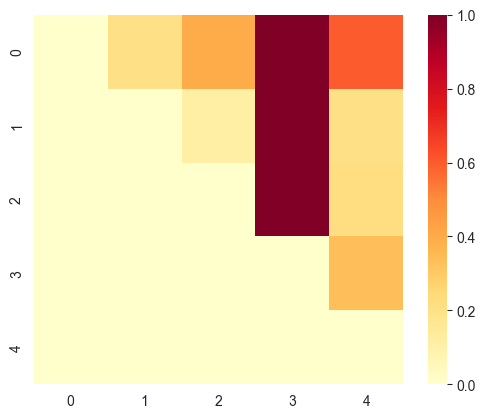

The average diversity of 5 MUSes generated by MARCO is: 0.5066666666666666


In [11]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} MUSes generated by MARCO is: {avg}")

In [12]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## 2 MARCO until diverse

In [13]:
result = []
top_indx, result, avg, div_matrix = marco_until_diverse(model.constraints, 5, 20)


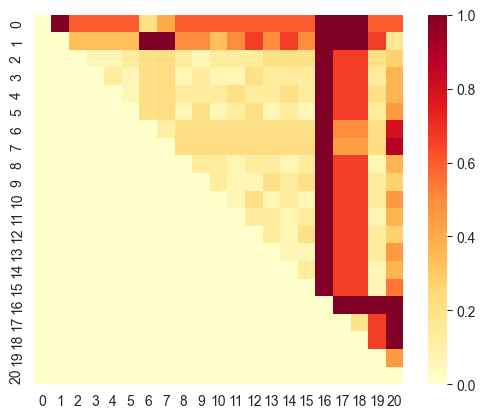

The average diversity of 5 most diverse MUSes generated by MARCO_until_diverse is: 0.91875
The selection of most diverse MUSes is: (0, 1, 16, 17, 18)


In [14]:
visualize_heatmap(div_matrix)
print(f"The average diversity of {len(result)} most diverse MUSes generated by MARCO_until_diverse is: {avg}")
print(f"The selection of most diverse MUSes is: {top_indx}")

## 3 MARCO select top k

In [15]:
top_indx, result, avg, div_matrix =  marco_select_top_k(model.constraints, 5, 20)

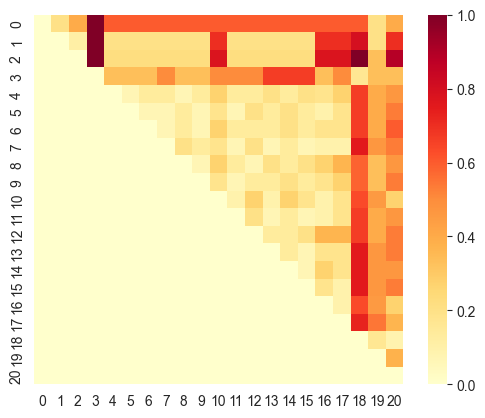

The average diversity of 5 most diverse MUSes generated by MARCO_select_top_k is: 0.6782828282828284


In [16]:
visualize_heatmap(div_matrix)
print(f"The average diversity of {len(result)} most diverse MUSes generated by MARCO_select_top_k is: {avg}")

In [17]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## 4 D-MARCO

In [18]:
result = []
for i, (kind, subset) in enumerate(marco_diverse(model.constraints, solver="exact", map_solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    if i == 4:
        break

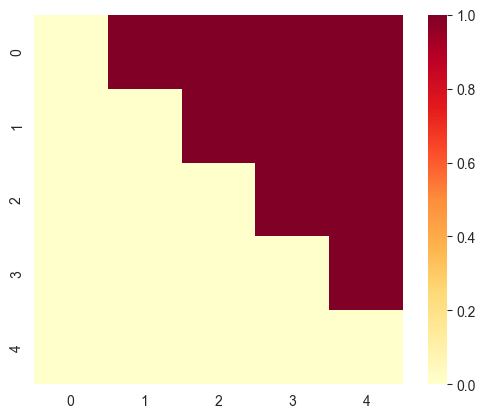

The average diversity of 5 first MUSes generated by MARCO_diverse is: 1.0


In [19]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} first MUSes generated by MARCO_diverse is: {avg}")

In [20]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## diversity measures

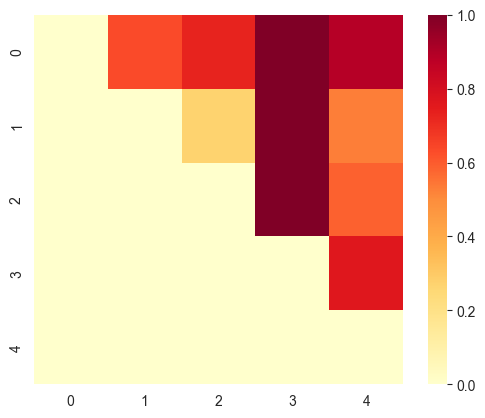

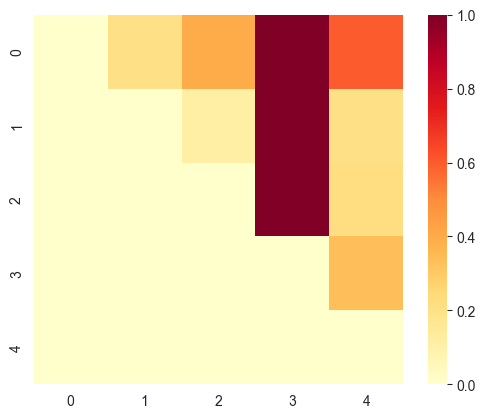

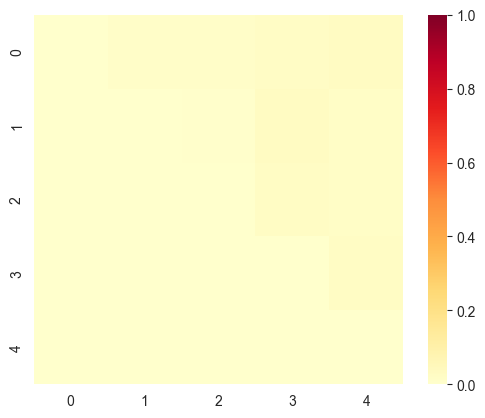

The average jacc diversity of the first 5 MUSes generated by MARCO is: 0.7407605466428995
The average overlap diversity of the first 5 MUSes generated by MARCO is: 0.5066666666666666
The average setdiff diversity of the first 5 MUSes generated by MARCO is: 0.01956521739130435


In [21]:
result = []
for i, (kind, subset) in enumerate(marco(model.constraints, solver="exact", map_solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    if i == 4:
        break

matrix_jacc = diversity_matrix(result, measure="Jaccard")
matrix_overlap = diversity_matrix(result, measure="overlap")
matrix_setdiff = diversity_matrix(result, c_size=len(model.constraints))
visualize_heatmap(matrix_jacc)
visualize_heatmap(matrix_overlap)
visualize_heatmap(matrix_setdiff)

avg_jacc = matrix_jacc[np.triu_indices_from(matrix_jacc, k=1)].mean()
avg_overlap = matrix_overlap[np.triu_indices_from(matrix_overlap, k=1)].mean()
avg_setdiff = matrix_setdiff[np.triu_indices_from(matrix_setdiff, k=1)].mean()
print(f"The average jacc diversity of the first {len(result)} MUSes generated by MARCO is: {avg_jacc}")
print(f"The average overlap diversity of the first {len(result)} MUSes generated by MARCO is: {avg_overlap}")
print(f"The average setdiff diversity of the first {len(result)} MUSes generated by MARCO is: {avg_setdiff}")